# ODE Benchmark Analysis

This notebook analyzes the ODE benchmark results saved under:

```text
test/bench/ode_solvers/logs
```

It expects:

```text
logs/latest_heavy_ode_benchmark.csv
```

Run the benchmark first from `test/bench/ode_solvers`:

```bash
./run_ode_benchmarks.sh
```

For a quicker run:

```bash
ODE_BENCH_PROFILE=quick ./run_ode_benchmarks.sh
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

LOG_DIR = Path("logs")
RESULT_PATH = LOG_DIR / "latest_heavy_ode_benchmark.csv"

if not RESULT_PATH.exists():
    alt = Path("test/bench/ode_solvers/logs/latest_heavy_ode_benchmark.csv")
    if alt.exists():
        RESULT_PATH = alt

print("Reading:", RESULT_PATH)
df = pd.read_csv(RESULT_PATH)

df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
df["error"] = pd.to_numeric(df["error"], errors="coerce")
df["T"] = pd.to_numeric(df["T"], errors="coerce")
df["D"] = pd.to_numeric(df["D"], errors="coerce")

df.head()


Reading: logs/latest_heavy_ode_benchmark.csv


,profile,timestamp,source_file,suite,problem,T,D,method,solver,backend,device,dtype,time_s,error,reference,notes,valid
0,extreme,20260609_205358,lsim_dense_T4096_D8_20260609_205358.csv,linear,linear_dense,4096,8,scipy_lsim,scipy,scipy,cpu,float64,0.018287,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN
1,extreme,20260609_205358,lsim_dense_T4096_D8_20260609_205358.csv,linear,linear_dense,4096,8,torch_scan_lsim,scan,torch,cuda,float32,0.006961,9.238720e-07,scipy_lsim,scan-based dense/diagonal lsim,NaN
2,extreme,20260609_205358,lsim_dense_T16384_D8_20260609_205358.csv,linear,linear_dense,16384,8,scipy_lsim,scipy,scipy,cpu,float64,0.096661,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN
3,extreme,20260609_205358,lsim_dense_T16384_D8_20260609_205358.csv,linear,linear_dense,16384,8,torch_scan_lsim,scan,torch,cuda,float32,0.008023,9.536743e-07,scipy_lsim,scan-based dense/diagonal lsim,NaN
4,extreme,20260609_205358,lsim_dense_T65536_D4_20260609_205358.csv,linear,linear_dense,65536,4,scipy_lsim,scipy,scipy,cpu,float64,0.187382,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN


## Raw benchmark table

In [2]:
df.sort_values(["suite", "problem", "T", "D", "method"]).reset_index(drop=True)


,profile,timestamp,source_file,suite,problem,T,D,method,solver,backend,device,dtype,time_s,error,reference,notes,valid
0,extreme,20260609_205358,lsim_dense_T2048_D100_20260609_205358.csv,linear,linear_dense,2048,100,scipy_lsim,scipy,scipy,cpu,float64,0.024395,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN
1,extreme,20260609_205358,lsim_dense_T2048_D100_20260609_205358.csv,linear,linear_dense,2048,100,torch_scan_lsim,scan,torch,cuda,float32,0.008602,1.996756e-05,scipy_lsim,scan-based dense/diagonal lsim,NaN
2,extreme,20260609_205358,lsim_dense_T4096_D8_20260609_205358.csv,linear,linear_dense,4096,8,scipy_lsim,scipy,scipy,cpu,float64,0.018287,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN
3,extreme,20260609_205358,lsim_dense_T4096_D8_20260609_205358.csv,linear,linear_dense,4096,8,torch_scan_lsim,scan,torch,cuda,float32,0.006961,9.238720e-07,scipy_lsim,scan-based dense/diagonal lsim,NaN
4,extreme,20260609_205358,lsim_dense_T8192_D32_20260609_205358.csv,linear,linear_dense,8192,32,scipy_lsim,scipy,scipy,cpu,float64,0.090088,0.000000e+00,scipy_lsim,scipy.signal.lsim interp=False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,extreme,20260609_205358,nonlinear_T65536_D8_20260609_205358.csv,nonlinear,rk4_nonlinear_8d,65536,8,deer_rk4_accel_scan_safe,deer,accel_scan,cuda,float32,0.216352,8.955598e-06,sequential_rk4,num_iters=6; requested_iters=256; tol=0.0001; ...,True
64,extreme,20260609_205358,nonlinear_T65536_D8_20260609_205358.csv,nonlinear,rk4_nonlinear_8d,65536,8,deer_rk4_torch_safe,deer,torch,cuda,float32,0.122763,9.864569e-06,sequential_rk4,num_iters=6; requested_iters=256; tol=0.0001; ...,True
65,extreme,20260609_205358,nonlinear_T65536_D8_20260609_205358.csv,nonlinear,rk4_nonlinear_8d,65536,8,elk_rk4_accel_scan,elk,accel_scan,cuda,float32,0.296898,1.233816e-05,sequential_rk4,num_iters=6; requested_iters=20; tol=1e-05; da...,True
66,extreme,20260609_205358,nonlinear_T65536_D8_20260609_205358.csv,nonlinear,rk4_nonlinear_8d,65536,8,elk_rk4_torch,elk,torch,cuda,float32,0.120543,3.725290e-05,sequential_rk4,num_iters=6; requested_iters=20; tol=1e-05; da...,True


## Fastest method per case

In [3]:
case_cols = ["suite", "problem", "T", "D"]

fastest = (
    df.dropna(subset=["time_s"])
      .sort_values("time_s")
      .groupby(case_cols, as_index=False)
      .first()
)

fastest[case_cols + ["method", "backend", "device", "dtype", "time_s", "error"]]


,suite,problem,T,D,method,backend,device,dtype,time_s,error
0,linear,linear_dense,2048,100,torch_scan_lsim,torch,cuda,float32,0.008602,1.996756e-05
1,linear,linear_dense,4096,8,torch_scan_lsim,torch,cuda,float32,0.006961,9.238720e-07
2,linear,linear_dense,8192,32,torch_scan_lsim,torch,cuda,float32,0.008647,4.306436e-06
3,linear,linear_dense,16384,8,torch_scan_lsim,torch,cuda,float32,0.008023,9.536743e-07
4,linear,linear_dense,65536,4,torch_scan_lsim,torch,cuda,float32,0.008677,7.152557e-07
5,linear,linear_diag,4096,8,accel_scan_lsim,accel_scan,cuda,float32,0.001589,1.251698e-06
6,linear,linear_diag,16384,8,accel_scan_lsim,accel_scan,cuda,float32,0.006373,1.251698e-06
7,linear,linear_diag,65536,4,torch_scan_lsim,torch,cuda,float32,0.006532,3.695488e-06
8,linear,linear_diag,65536,32,torch_scan_lsim,torch,cuda,float32,0.007104,3.171712e-05
9,linear,linear_diag,65536,100,torch_scan_lsim,torch,cuda,float32,0.008505,5.144626e-05


## Linear-system speedups relative to SciPy lsim

In [4]:
linear = df[df["suite"] == "linear"].copy()

scipy = (
    linear[linear["method"] == "scipy_lsim"]
    .set_index(["problem", "T", "D"])["time_s"]
)

linear["scipy_time_s"] = linear.set_index(["problem", "T", "D"]).index.map(scipy)
linear["speedup_vs_scipy"] = linear["scipy_time_s"] / linear["time_s"]

linear.sort_values(["problem", "T", "D", "method"])[
    ["problem", "T", "D", "method", "backend", "time_s", "scipy_time_s", "speedup_vs_scipy", "error"]
]


,problem,T,D,method,backend,time_s,scipy_time_s,speedup_vs_scipy,error
8,linear_dense,2048,100,scipy_lsim,scipy,0.024395,0.024395,1.000000,0.000000e+00
9,linear_dense,2048,100,torch_scan_lsim,torch,0.008602,0.024395,2.836154,1.996756e-05
0,linear_dense,4096,8,scipy_lsim,scipy,0.018287,0.018287,1.000000,0.000000e+00
1,linear_dense,4096,8,torch_scan_lsim,torch,0.006961,0.018287,2.626906,9.238720e-07
6,linear_dense,8192,32,scipy_lsim,scipy,0.090088,0.090088,1.000000,0.000000e+00
7,linear_dense,8192,32,torch_scan_lsim,torch,0.008647,0.090088,10.418329,4.306436e-06
2,linear_dense,16384,8,scipy_lsim,scipy,0.096661,0.096661,1.000000,0.000000e+00
3,linear_dense,16384,8,torch_scan_lsim,torch,0.008023,0.096661,12.047663,9.536743e-07
4,linear_dense,65536,4,scipy_lsim,scipy,0.187382,0.187382,1.000000,0.000000e+00
5,linear_dense,65536,4,torch_scan_lsim,torch,0.008677,0.187382,21.595821,7.152557e-07


## Nonlinear ODE speedups relative to sequential RK4

In [5]:
nonlinear = df[df["suite"] == "nonlinear"].copy()

seq = (
    nonlinear[nonlinear["method"] == "sequential_rk4"]
    .set_index(["problem", "T", "D"])["time_s"]
)

nonlinear["sequential_time_s"] = nonlinear.set_index(["problem", "T", "D"]).index.map(seq)
nonlinear["speedup_vs_sequential"] = nonlinear["sequential_time_s"] / nonlinear["time_s"]

nonlinear.sort_values(["problem", "T", "D", "method"])[
    ["problem", "T", "D", "method", "backend", "time_s", "sequential_time_s", "speedup_vs_sequential", "error"]
]


,problem,T,D,method,backend,time_s,sequential_time_s,speedup_vs_sequential,error
32,rk4_nonlinear_1d,1024,1,deer_rk4_accel_scan_safe,accel_scan,0.020127,0.334899,16.639052,0.000001
31,rk4_nonlinear_1d,1024,1,deer_rk4_torch_safe,torch,0.014942,0.334899,22.413121,0.000001
30,rk4_nonlinear_1d,1024,1,elk_rk4_accel_scan,accel_scan,0.036904,0.334899,9.074950,0.000001
29,rk4_nonlinear_1d,1024,1,elk_rk4_torch,torch,0.037180,0.334899,9.007588,0.000021
28,rk4_nonlinear_1d,1024,1,sequential_rk4,python_loop,0.334899,0.334899,1.000000,0.000000
37,rk4_nonlinear_1d,4096,1,deer_rk4_accel_scan_safe,accel_scan,0.015748,1.278787,81.204060,0.000003
36,rk4_nonlinear_1d,4096,1,deer_rk4_torch_safe,torch,0.030616,1.278787,41.768933,0.000003
35,rk4_nonlinear_1d,4096,1,elk_rk4_accel_scan,accel_scan,0.040534,1.278787,31.548725,0.000005
34,rk4_nonlinear_1d,4096,1,elk_rk4_torch,torch,0.039027,1.278787,32.766430,0.000043
33,rk4_nonlinear_1d,4096,1,sequential_rk4,python_loop,1.278787,1.278787,1.000000,0.000000


## Runtime plots

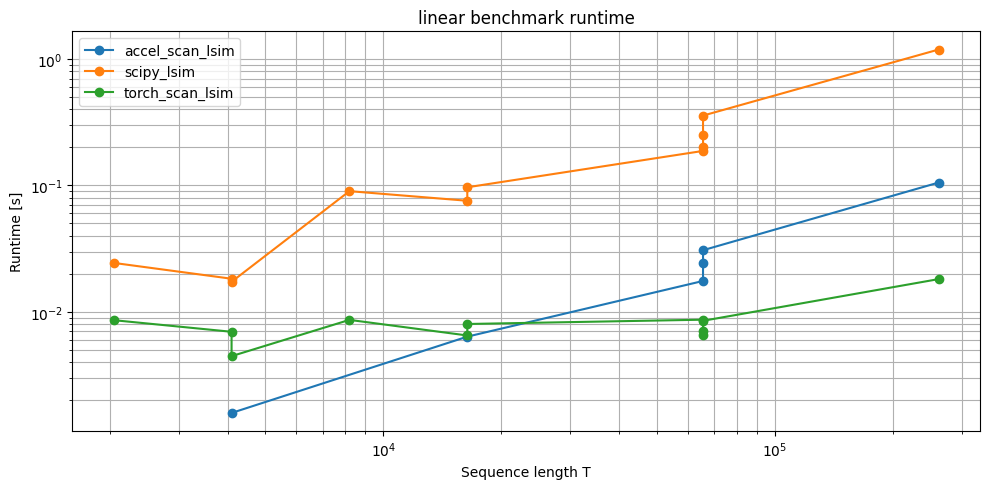

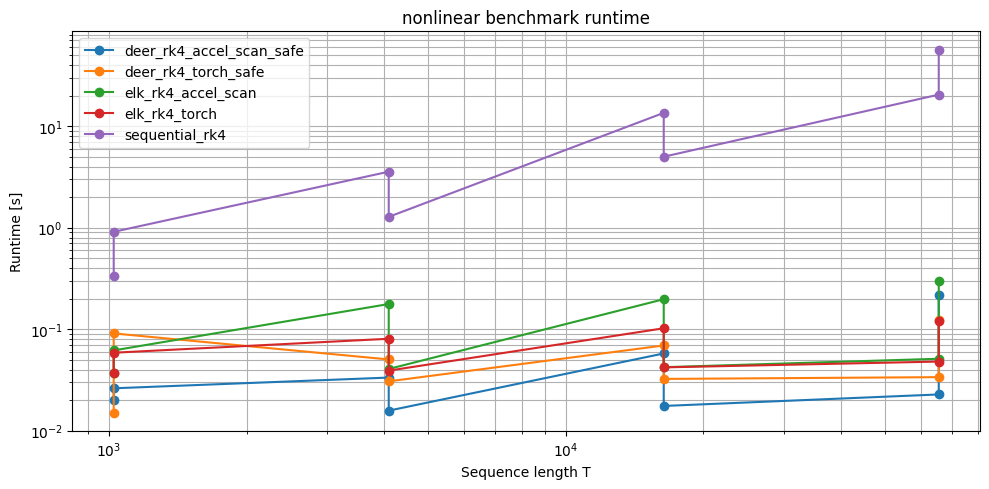

In [6]:
plot_df = df.dropna(subset=["time_s"]).copy()

for suite_name, sub in plot_df.groupby("suite"):
    plt.figure(figsize=(10, 5))

    for method, g in sub.groupby("method"):
        g = g.sort_values("T")
        plt.plot(g["T"], g["time_s"], marker="o", linestyle="-", label=method)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Sequence length T")
    plt.ylabel("Runtime [s]")
    plt.title(f"{suite_name} benchmark runtime")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Speedup plots

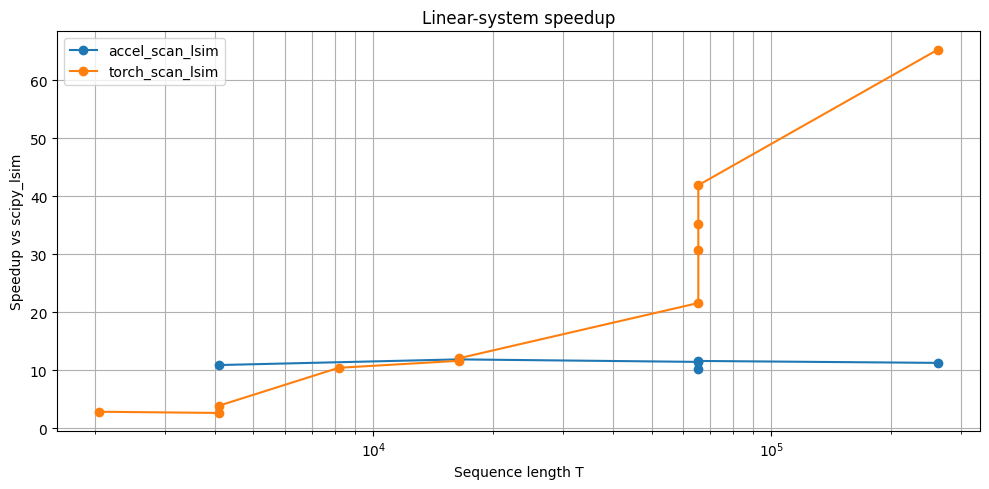

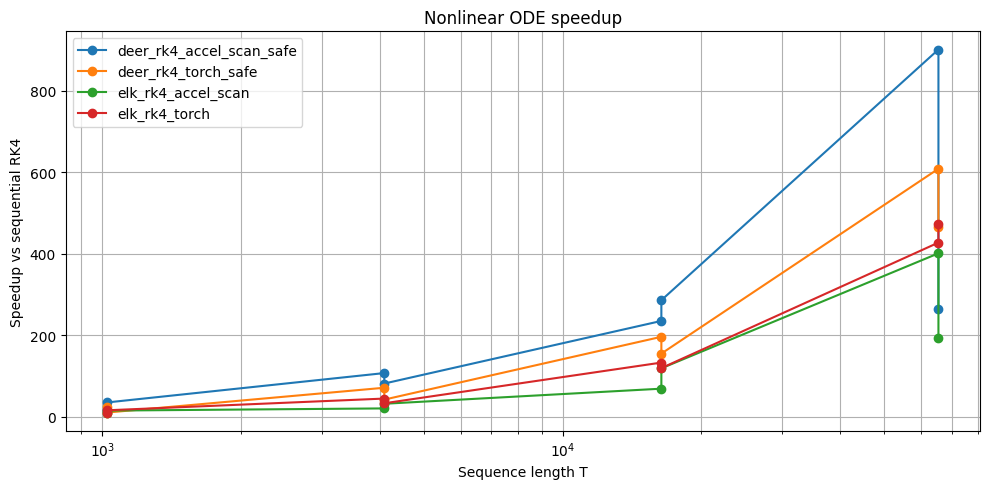

In [7]:
linear_speed = linear.dropna(subset=["speedup_vs_scipy"])
linear_speed = linear_speed[np.isfinite(linear_speed["speedup_vs_scipy"])]

if len(linear_speed):
    plt.figure(figsize=(10, 5))

    for method, g in linear_speed.groupby("method"):
        if method == "scipy_lsim":
            continue

        g = g.sort_values("T")
        plt.plot(g["T"], g["speedup_vs_scipy"], marker="o", label=method)

    plt.xscale("log")
    plt.xlabel("Sequence length T")
    plt.ylabel("Speedup vs scipy_lsim")
    plt.title("Linear-system speedup")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

nonlinear_speed = nonlinear.dropna(subset=["speedup_vs_sequential"])
nonlinear_speed = nonlinear_speed[np.isfinite(nonlinear_speed["speedup_vs_sequential"])]

if len(nonlinear_speed):
    plt.figure(figsize=(10, 5))

    for method, g in nonlinear_speed.groupby("method"):
        if method == "sequential_rk4":
            continue

        g = g.sort_values("T")
        plt.plot(g["T"], g["speedup_vs_sequential"], marker="o", label=method)

    plt.xscale("log")
    plt.xlabel("Sequence length T")
    plt.ylabel("Speedup vs sequential RK4")
    plt.title("Nonlinear ODE speedup")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Accuracy summary

In [8]:
accuracy = (
    df.groupby(["suite", "method", "backend"], dropna=False)
      .agg(
          max_error=("error", "max"),
          median_error=("error", "median"),
          min_time=("time_s", "min"),
          median_time=("time_s", "median"),
          count=("time_s", "count"),
      )
      .reset_index()
      .sort_values(["suite", "median_time"])
)

accuracy


,suite,method,backend,max_error,median_error,min_time,median_time,count
2,linear,torch_scan_lsim,torch,0.000051,0.000006,0.004469,0.008023,11
0,linear,accel_scan_lsim,accel_scan,0.000009,0.000003,0.001589,0.020960,6
1,linear,scipy_lsim,scipy,0.000000,0.000000,0.017299,0.096661,11
3,nonlinear,deer_rk4_accel_scan_safe,accel_scan,0.000009,0.000004,0.015748,0.024438,8
4,nonlinear,deer_rk4_torch_safe,torch,0.000010,0.000004,0.014942,0.041987,8
6,nonlinear,elk_rk4_torch,torch,0.000043,0.000038,0.037180,0.053284,8
5,nonlinear,elk_rk4_accel_scan,accel_scan,0.000013,0.000007,0.036904,0.056422,8
7,nonlinear,sequential_rk4,python_loop,0.000000,0.000000,0.334899,4.284431,8
